--- カテゴリ別集計 ---
                       Sales       Profit
Category                                 
Furniture        741999.7953   18451.2728
Office Supplies  719047.0320  122490.8008
Technology       836154.0330  145454.9481


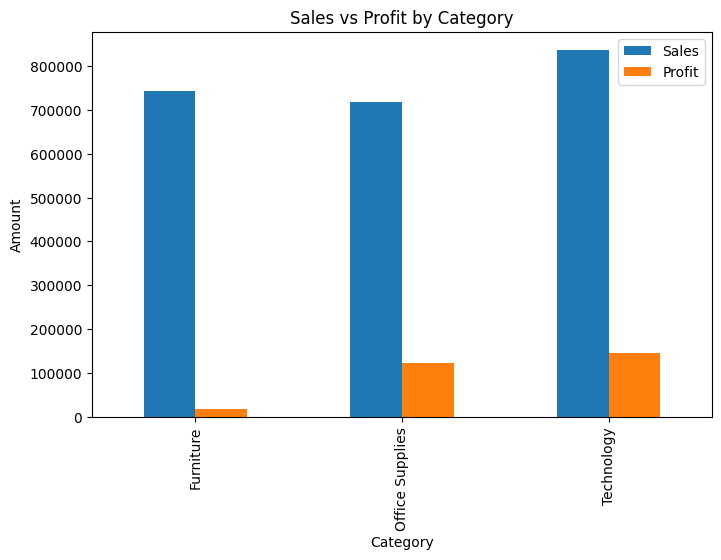


--- サブカテゴリ別利益（ワースト順） ---
Sub-Category
Tables      -17725.4811
Bookcases    -3472.5560
Supplies     -1189.0995
Fasteners      949.5182
Machines      3384.7569
Name: Profit, dtype: float64

--- テーブルの地域別利益 ---
Region
Central    -3559.6504
East      -11025.3801
South      -4623.0579
West        1482.6073
Name: Profit, dtype: float64

Excelファイル 'Sales_Analysis_Report.xlsx' を作成しました。


In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# データの読み込み
df = pd.read_csv('data\SampleSuperstore.csv')

# --- 1. カテゴリ別の売上と利益の集計 ---
# カテゴリごとに売上（Sales）と利益（Profit）の合計を計算します
cat_analysis = df.groupby("Category")[["Sales", "Profit"]].sum()
print("--- カテゴリ別集計 ---")
print(cat_analysis)

# グラフの表示（figsizeでグラフのサイズを調整）
cat_analysis.plot(kind='bar', figsize=(8, 5))
plt.title("Sales vs Profit by Category") # カテゴリ別の売上と利益
plt.ylabel("Amount") # 金額
plt.show()

# --- 2. サブカテゴリ別の利益（赤字商品の特定） ---
# 利益の低い順に並べ替えて、ワースト5を抽出します
sub_profit = df.groupby("Sub-Category")["Profit"].sum().sort_values()
print("\n--- サブカテゴリ別利益（ワースト順） ---")
print(sub_profit.head()) 

# --- 3. 特定の赤字商品「Tables（テーブル）」の地域別分析 ---
# 最も赤字が大きい「Tables」のみを抽出し、地域（Region）ごとに利益を合算します
tables_df = df[df["Sub-Category"] == "Tables"]
region_tables = tables_df.groupby("Region")["Profit"].sum()
print("\n--- テーブルの地域別利益 ---")
print(region_tables)

# --- 4. 分析結果をExcelファイルに出力 ---
# 複数の分析結果を、別々のシートに分けて一つのExcelファイルとして保存します
with pd.ExcelWriter('Sales_Analysis_Report.xlsx') as writer:
    cat_analysis.to_excel(writer, sheet_name='Category_Summary') # カテゴリ別集計
    sub_profit.to_excel(writer, sheet_name='SubCategory_Loss')    # サブカテゴリ別利益
    region_tables.to_excel(writer, sheet_name='Tables_By_Region') # テーブル地域別利益

print("\nExcelファイル 'Sales_Analysis_Report.xlsx' を作成しました。")